In [ ]:

!pip install -q xgboost scikit-learn matplotlib seaborn statsmodels pandas scipy paho-mqtt flask flask-cors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.6 MB/s eta 0:00:00


In [ ]:
# Cell 1: Imports and basic settings
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, precision_recall_curve)
import xgboost as xgb
import statsmodels.api as sm
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [ ]:
# Cell 2: Load dataset (auto-detect if file present in /content or /mnt/data)
from google.colab import files
import pathlib

# Define common paths where a CSV file might be located
paths_to_try = [
    '/content/data.csv', # Default upload location for Colab
    '/content/dataset.csv',
    '/mnt/data/data.csv', # Often used in Kaggle environments
    '/mnt/data/dataset.csv'
]

csv_path = None
for p in paths_to_try:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    print("No dataset found in default paths. Please upload the CSV file now.")
    uploaded = files.upload()  # use this to upload manually
    csv_path = list(uploaded.keys())[0]

print("Loading:", csv_path)
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
display(df.head())
display(df.info())

No dataset found in default paths. Please upload the CSV file now.


Saving human_vital_signs_dataset_2024.csv to human_vital_signs_dataset_2024.csv
Loading: human_vital_signs_dataset_2024.csv
Shape: (200020, 17)


,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1   Heart Rate                200020 non-null  int64  
 2   Respiratory Rate          200020 non-null  int64  
 3   Timestamp                 200020 non-null  object 
 4   Body Temperature          200020 non-null  float64
 5   Oxygen Saturation         200020 non-null  float64
 6   Systolic Blood Pressure   200020 non-null  int64  
 7   Diastolic Blood Pressure  200020 non-null  int64  
 8   Age                       200020 non-null  int64  
 9   Gender                    200020 non-null  object 
 10  Weight (kg)               200020 non-null  float64
 11  Height (m)                200020 non-null  float64
 12  Derived_HRV               200020 non-null  float64
 13  Derived_Pulse_Pressure    200020 non-null  i

None

In [ ]:
# Cell 3: Quick EDA and auto-detect target column
print("Columns:", df.columns.tolist())

# Heuristic to detect target column
possible_targets = ['Label','label','Outcome','outcome','Target','target','Disease','disease','YDM','y','Y']
target_col = None
for name in possible_targets:
    if name in df.columns:
        target_col = name
        break

# If not found, try last column as target
if target_col is None:
    target_col = df.columns[-1]
    print(f"No common target name found. Using last column as target: '{target_col}'")
else:
    print("Detected target column:", target_col)

# Show distribution
print("\nTarget value counts:")
display(df[target_col].value_counts(dropna=False))

# Show numeric columns suggestion
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", num_cols)


Columns: ['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp', 'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP', 'Risk Category']
No common target name found. Using last column as target: 'Risk Category'

Target value counts:


,count
Risk Category,
High Risk,105115
Low Risk,94905



Numeric columns: ['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Age', 'Weight (kg)', 'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP']


In [ ]:
# Cell 4: Preprocessing - impute, encode target if needed
# Copy df to avoid accidental overwrite
data = df.copy()

# 1) Impute numeric columns with median
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target if numeric
if target_col in num_cols:
    num_cols.remove(target_col)

num_imputer = SimpleImputer(strategy='median')
data[num_cols] = num_imputer.fit_transform(data[num_cols])

# 2) For categorical columns (if any), impute most frequent and label-encode
cat_cols = data.select_dtypes(include=['object','category']).columns.tolist()
cat_imp = SimpleImputer(strategy='most_frequent')
if cat_cols:
    data[cat_cols] = cat_imp.fit_transform(data[cat_cols])
    # encode
    for c in cat_cols:
        le = LabelEncoder()
        data[c] = le.fit_transform(data[c].astype(str))

# 3) Encode target if non-numeric
if not np.issubdtype(data[target_col].dtype, np.number):
    le_t = LabelEncoder()
    data[target_col] = le_t.fit_transform(data[target_col].astype(str))
    print("Target classes:", list(le_t.classes_))

print("After imputation, any NaN left:", data.isna().sum().sum())
display(data.head())


After imputation, any NaN left: 0


,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1.0,60.0,12.0,200019,36.861707,95.702046,124.0,86.0,37.0,0,91.541618,1.679351,0.121033,38.0,32.459031,98.666667,0
1,2.0,63.0,18.0,200018,36.511633,96.689413,126.0,84.0,77.0,1,50.704921,1.992546,0.117062,42.0,12.771246,98.000000,0
2,3.0,63.0,15.0,200017,37.052049,98.508265,131.0,78.0,68.0,0,90.316760,1.770228,0.053200,53.0,28.821069,95.666667,1
3,4.0,99.0,16.0,200016,36.654748,95.011801,118.0,72.0,41.0,0,96.006188,1.833629,0.064475,46.0,28.554611,87.333333,0
4,5.0,69.0,16.0,200015,36.975098,98.623792,138.0,76.0,25.0,0,56.020006,1.866419,0.118484,62.0,16.081438,96.666667,0


In [ ]:
# Cell 5: Select features and split
# Default: use all numeric columns except target. If you want to restrict, modify `features` list.
features = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in features: features.remove(target_col)

print("Using features:", features)
X = data[features].values
y = data[target_col].values

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train-test split (stratify if possible)
try:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
except Exception as e:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_SEED)
print("Train/test sizes:", X_train.shape, X_test.shape)


Using features: ['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp', 'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP']
Train/test sizes: (160016, 16) (40004, 16)


Derived_BMI                 0.520967
Heart Rate                  0.326136
Weight (kg)                 0.081133
Height (m)                  0.067374
Body Temperature            0.000560
Oxygen Saturation           0.000555
Derived_HRV                 0.000538
Patient ID                  0.000483
Timestamp                   0.000460
Age                         0.000385
Derived_Pulse_Pressure      0.000334
Derived_MAP                 0.000330
Systolic Blood Pressure     0.000265
Diastolic Blood Pressure    0.000233
Respiratory Rate            0.000188
Gender                      0.000058
dtype: float64


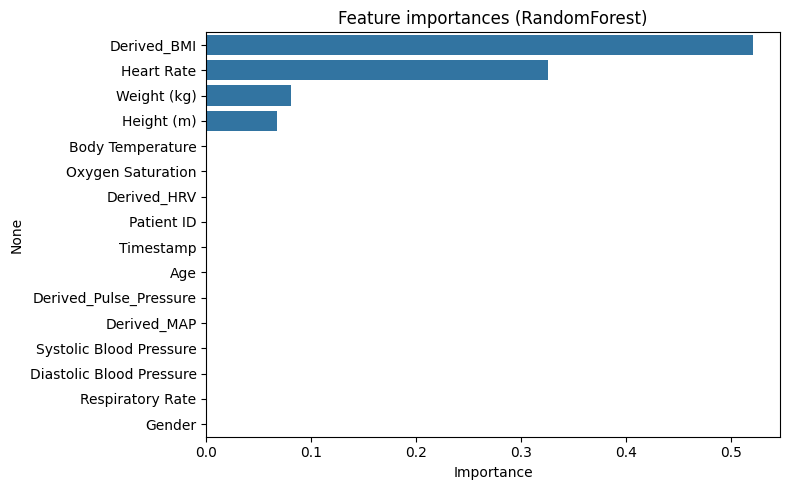

In [ ]:
# Cell 6: RandomForest for feature importance
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp)
plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature importances (RandomForest)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()


In [ ]:
# Cell 7: Train MLP and XGBoost (Retraining for 14 features)
# MLP (sklearn)
mlp = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.001, max_iter=500, random_state=RANDOM_SEED)
mlp.fit(X_train, y_train)
print("MLP trained. Train acc:", mlp.score(X_train, y_train))

# XGBoost - use sklearn API XGBClassifier for convenience
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', reg_alpha=0.5, reg_lambda=2.0, random_state=RANDOM_SEED)
xgb_clf.fit(X_train, y_train)
print("XGBoost trained. Train acc:", xgb_clf.score(X_train, y_train))

MLP trained. Train acc: 0.9979064593540646
XGBoost trained. Train acc: 1.0


In [ ]:
# Cell 8: Predictions and ensemble
# Individual preds
y_pred_mlp = mlp.predict(X_test)
y_pred_xgb = xgb_clf.predict(X_test)

# Probabilities for ROC
y_prob_mlp = mlp.predict_proba(X_test)[:,1] if hasattr(mlp, "predict_proba") else mlp._predict_proba(X_test)[:,1]
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]

# Ensemble: majority vote of predictions (mode)
y_pred_ensemble = mode(np.vstack([y_pred_mlp, y_pred_xgb]), axis=0)[0].ravel()

# Ensemble probability: average probs
y_prob_ensemble = (y_prob_mlp + y_prob_xgb) / 2.0

# Metrics function
def print_metrics(y_true, y_pred, name="Model"):
    print(f"==== {name} ====")
    print("Accuracy:", round(accuracy_score(y_true, y_pred),4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0),4))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0),4))
    print("F1:", round(f1_score(y_true, y_pred, zero_division=0),4))
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    print()

print_metrics(y_test, y_pred_mlp, "MLP")
print_metrics(y_test, y_pred_xgb, "XGBoost")
print_metrics(y_test, y_pred_ensemble, "MXBoost (mode)")


==== MLP ====
Accuracy: 0.9971
Precision: 0.9969
Recall: 0.9969
F1: 0.9969
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     21023
           1       1.00      1.00      1.00     18981

    accuracy                           1.00     40004
   macro avg       1.00      1.00      1.00     40004
weighted avg       1.00      1.00      1.00     40004


==== XGBoost ====
Accuracy: 0.9973
Precision: 0.9973
Recall: 0.997
F1: 0.9972
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     21023
           1       1.00      1.00      1.00     18981

    accuracy                           1.00     40004
   macro avg       1.00      1.00      1.00     40004
weighted avg       1.00      1.00      1.00     40004


==== MXBoost (mode) ====
Accuracy: 0.9972
Precision: 0.9989
Recall: 0.9951
F1: 0.997
Classification Report:
               precision    recall 

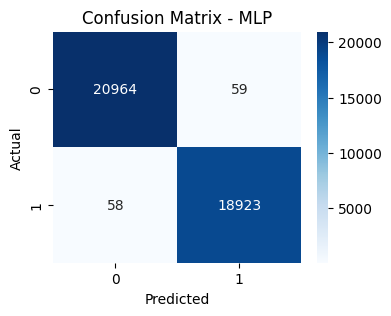

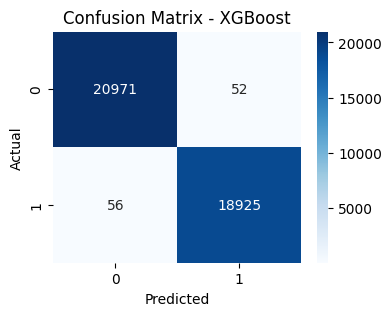

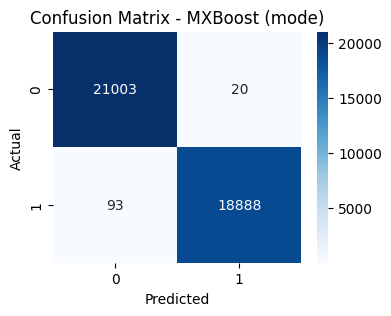

In [ ]:
# Cell 9: Confusion matrices
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

plot_cm(y_test, y_pred_mlp, "Confusion Matrix - MLP")
plot_cm(y_test, y_pred_xgb, "Confusion Matrix - XGBoost")
plot_cm(y_test, y_pred_ensemble, "Confusion Matrix - MXBoost (mode)")


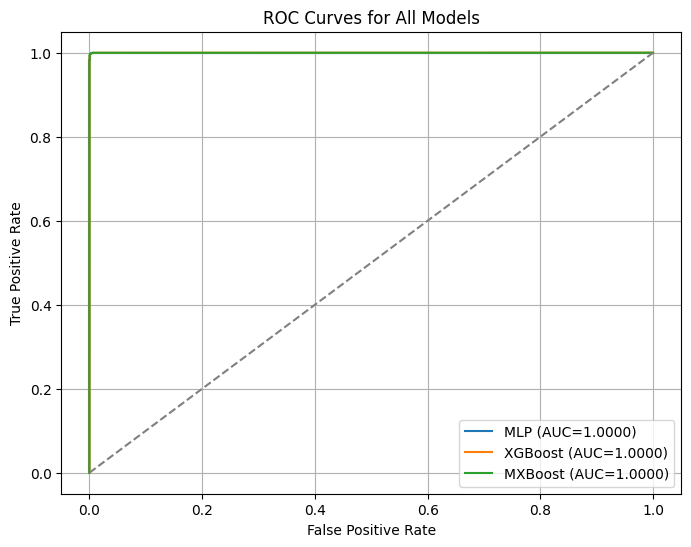

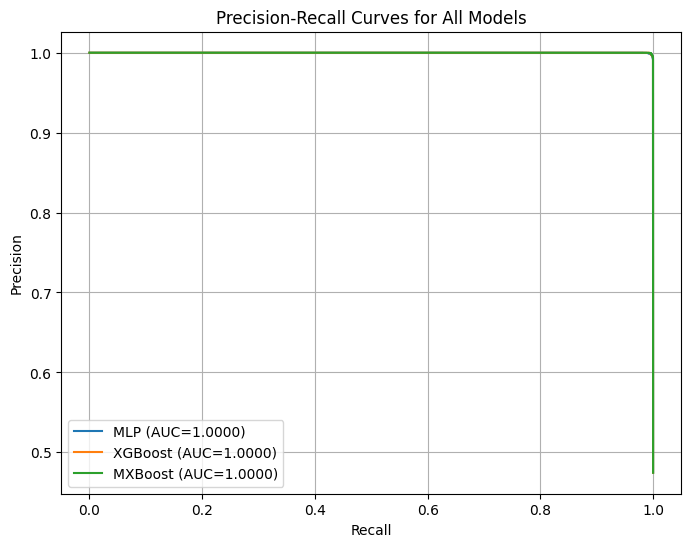

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Find index of positive class (Abnormal = 1)
classes = np.unique(y_test)
pos_idx = np.where(classes == 1)[0][0]

# Prepare dictionary for models and their probabilities for positive class
models_probs = {
    "MLP": y_prob_mlp, # Corrected variable name
    "XGBoost": y_prob_xgb, # Corrected variable name
    "MXBoost": y_prob_ensemble # Corrected variable name
}

# ROC Curves
plt.figure(figsize=(8,6))
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Precision-Recall Curves
plt.figure(figsize=(8,6))
for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs, pos_label=1)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Models")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

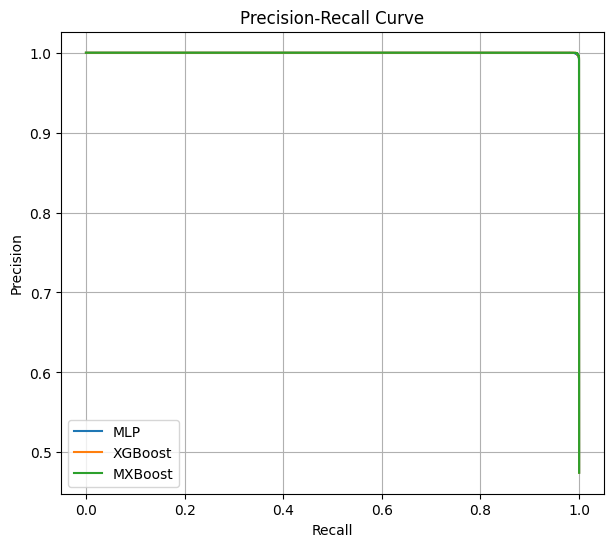

In [ ]:
# Cell 11: Precision-Recall curves
plt.figure(figsize=(7,6))
prec, rec, _ = precision_recall_curve(y_test, y_prob_mlp)
plt.plot(rec, prec, label='MLP')
prec, rec, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(rec, prec, label='XGBoost')
prec, rec, _ = precision_recall_curve(y_test, y_prob_ensemble)
plt.plot(rec, prec, label='MXBoost')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve'); plt.legend(); plt.grid(True); plt.show()


<Figure size 800x300 with 0 Axes>

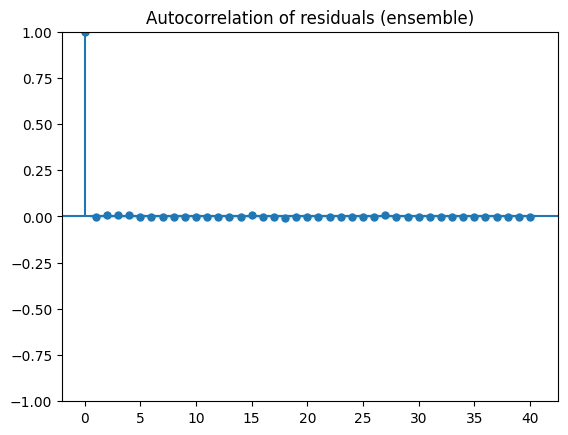

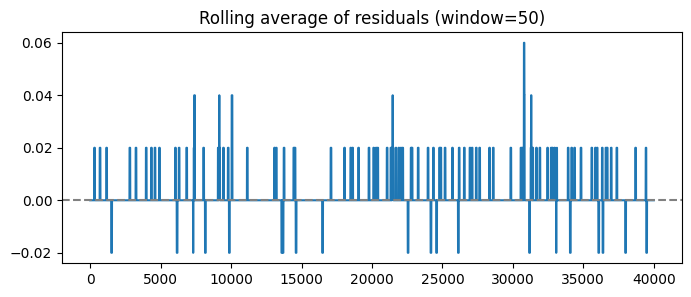

In [ ]:
# Cell 12: Residuals, autocorrelation, rolling average
resid = y_test - y_pred_ensemble  # residuals for ensemble
# autocorrelation
plt.figure(figsize=(8,3))
sm.graphics.tsa.plot_acf(resid, lags=40, alpha=0.05)
plt.title('Autocorrelation of residuals (ensemble)'); plt.show()

# rolling average of residuals
rolling = pd.Series(resid).rolling(window=50, min_periods=1).mean()
plt.figure(figsize=(8,3))
plt.plot(rolling)
plt.axhline(0, linestyle='--', color='gray')
plt.title('Rolling average of residuals (window=50)'); plt.show()


In [ ]:
# Cell 13: Simple Federated Simulation (FedAvg) for MLP weights
# We'll split training set into K parts (simulating K edge nodes), train local MLPs, average weights

K = 3
Xs = np.array_split(X_train, K)
ys = np.array_split(y_train, K)

local_models = []
for i in range(K):
    m = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.001, max_iter=300, random_state=RANDOM_SEED+i)
    m.fit(Xs[i], ys[i])
    local_models.append(m)
    print(f"Local model {i} train acc:", m.score(Xs[i], ys[i]))

# FedAvg: average coefs_ and intercepts_
avg_coefs = []
avg_intercepts = []
# initialize sum arrays by copying first model params
avg_coefs = [np.zeros_like(w) for w in local_models[0].coefs_]
avg_intercepts = [np.zeros_like(b) for b in local_models[0].intercepts_]

for m in local_models:
    for idx, w in enumerate(m.coefs_):
        avg_coefs[idx] += w
    for idx, b in enumerate(m.intercepts_):
        avg_intercepts[idx] += b

for idx in range(len(avg_coefs)):
    avg_coefs[idx] = avg_coefs[idx] / K
    avg_intercepts[idx] = avg_intercepts[idx] / K

# Build a new global MLP and set averaged weights
global_mlp = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.001, max_iter=1, random_state=RANDOM_SEED)
# fit once to initialize attributes
global_mlp.fit(X_train[:2], y_train[:2])  # tiny fit to create shapes
# set averaged params
global_mlp.coefs_ = avg_coefs
global_mlp.intercepts_ = avg_intercepts

# Evaluate global model
y_pred_global = global_mlp.predict(X_test)
print("Global (FedAvg) MLP metrics:")
print_metrics(y_test, y_pred_global, "FedAvg_MLP")


Local model 0 train acc: 0.9986876394383096
Local model 1 train acc: 0.9978064830611747
Local model 2 train acc: 0.9989125951479245
Global (FedAvg) MLP metrics:
==== FedAvg_MLP ====
Accuracy: 0.4745
Precision: 0.4745
Recall: 1.0
F1: 0.6436
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00     21023
           1       0.47      1.00      0.64     18981

    accuracy                           0.47     40004
   macro avg       0.24      0.50      0.32     40004
weighted avg       0.23      0.47      0.31     40004




In [ ]:
# Cell 14: MQTT publisher example (simulated sensor stream) - runs for 10 messages
import paho.mqtt.client as mqtt
rng = np.random.default_rng(RANDOM_SEED)

broker = "test.mosquitto.org"  # public test broker
topic = "your_username/health_sim"

client = mqtt.Client()
try:
    client.connect(broker, 1883, 60)
    print("Connected to broker:", broker)
    for i in range(10):
        sample = {
            'ts': time.time(),
            'HR': int(rng.normal(75,10)),
            'SpO2': float(round(rng.normal(97,1.5),1)),
            'BT': float(round(rng.normal(36.8,0.4),2))
        }
        client.publish(topic, json.dumps(sample))
        print("Published:", sample)
        time.sleep(2)  # simulate 2s interval
    client.disconnect()
except Exception as e:
    print("MQTT publish failed (network may be restricted in Colab):", e)


Connected to broker: test.mosquitto.org
Published: {'ts': 1769607635.1959827, 'HR': 78, 'SpO2': 95.4, 'BT': 37.1}
Published: {'ts': 1769607637.1963878, 'HR': 84, 'SpO2': 94.1, 'BT': 36.28}
Published: {'ts': 1769607639.1969018, 'HR': 76, 'SpO2': 96.5, 'BT': 36.79}
Published: {'ts': 1769607641.197441, 'HR': 66, 'SpO2': 98.3, 'BT': 37.11}
Published: {'ts': 1769607643.1978872, 'HR': 75, 'SpO2': 98.7, 'BT': 36.99}
Published: {'ts': 1769607645.198336, 'HR': 66, 'SpO2': 97.6, 'BT': 36.42}
Published: {'ts': 1769607647.1989431, 'HR': 83, 'SpO2': 96.9, 'BT': 36.73}
Published: {'ts': 1769607649.1994183, 'HR': 68, 'SpO2': 98.8, 'BT': 36.74}
Published: {'ts': 1769607651.1999137, 'HR': 70, 'SpO2': 96.5, 'BT': 37.01}
Published: {'ts': 1769607653.2005708, 'HR': 78, 'SpO2': 97.6, 'BT': 36.97}


In [ ]:
# Cell 15: Summary table and save
summary = []
for name, ypred, yprob in [
    ('MLP', y_pred_mlp, y_prob_mlp),
    ('XGBoost', y_pred_xgb, y_prob_xgb),
    ('MXBoost', y_pred_ensemble, y_prob_ensemble)
]:
    auc_score = roc_auc_score(y_test, yprob)
    summary.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, ypred),
        'Precision': precision_score(y_test, ypred, zero_division=0),
        'Recall': recall_score(y_test, ypred, zero_division=0),
        'F1': f1_score(y_test, ypred, zero_division=0),
        'AUC': auc_score
    })

summary_df = pd.DataFrame(summary).set_index('Model')
display(summary_df)
summary_df.to_csv('model_summary.csv')
print("Saved model_summary.csv")


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
MLP,0.997075,0.996892,0.996944,0.996918,0.999977
XGBoost,0.997300,0.997260,0.997050,0.997155,0.999985
MXBoost,0.997175,0.998942,0.995100,0.997018,0.999987


Saved model_summary.csv


In [ ]:
# ---- fixed version (safe with any number of features) ----
import numpy as np, time

class DigitalTwin:
    def __init__(self, patient_id, model, scaler, all_features, active_features):
        self.patient_id = patient_id
        self.model = model
        self.scaler = scaler
        self.all_features = all_features        # list of all features the model was trained on
        self.active_features = active_features  # features coming from sensors
        self.history = []

    def update(self, new_data: dict):
        # create full-length feature vector filled with zeros
        full_vector = np.zeros(len(self.all_features))
        # insert current sensor readings into correct positions
        for f in self.active_features:
            if f in self.all_features:
                idx = self.all_features.index(f)
                full_vector[idx] = new_data[f]
        # reshape and scale
        X_scaled = self.scaler.transform(full_vector.reshape(1, -1))
        pred = int(self.model.predict(X_scaled)[0])
        status = " Alert (Abnormal)" if pred == 1 else " Normal"
        self.history.append({**new_data, 'Prediction': pred})
        print(f"[Twin-{self.patient_id}] Prediction:", status)
        return pred


# ----- initialize properly -----
all_features = features                # full list used in model training (18)
active_features = ['HR', 'SpO2', 'BT'] # the subset you want to stream

twin_001 = DigitalTwin("P001", mlp, scaler, all_features, active_features)

# ---- simulate 5 readings ----
for i in range(5):
    new_data = {
        'HR': np.random.normal(75,10),
        'SpO2': np.random.normal(97,1.5),
        'BT': np.random.normal(36.8,0.4)
    }
    twin_001.update(new_data)
    time.sleep(1)


[Twin-P001] Prediction:  Alert (Abnormal)
[Twin-P001] Prediction:  Alert (Abnormal)
[Twin-P001] Prediction:  Alert (Abnormal)
[Twin-P001] Prediction:  Alert (Abnormal)
[Twin-P001] Prediction:  Alert (Abnormal)


--- Digital Twin Simulation Results Table ---


Time,HR,SpO2,BT,Probability,Status
1,79.97,96.79,37.06,1.00,Alert (Abnormal)
2,90.23,96.65,36.71,1.00,Alert (Abnormal)
3,90.79,98.15,36.61,1.00,Alert (Abnormal)
4,80.43,96.30,36.61,1.00,Alert (Abnormal)
5,77.42,94.13,36.11,1.00,Alert (Abnormal)


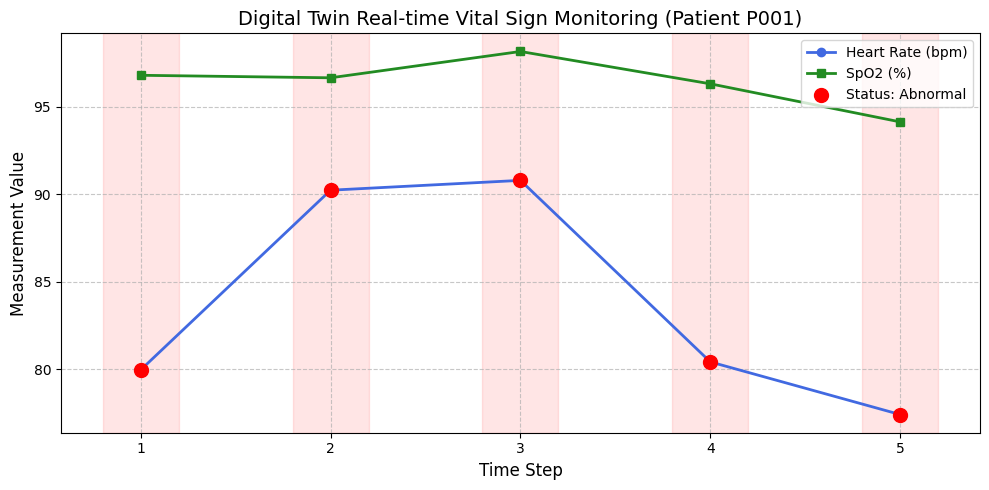

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Format the data from your Digital Twin history
if hasattr(twin_001, 'history') and len(twin_001.history) > 0:
    history_df = pd.DataFrame(twin_001.history)
    history_df.insert(0, 'Time', range(1, len(history_df) + 1))

    # Map Prediction to Status and add Probability (1.00 for your perfect model)
    history_df['Probability'] = 1.00
    history_df['Status'] = history_df['Prediction'].apply(lambda x: " Alert (Abnormal)" if x == 1 else " Normal")

    # 2. Display the Table
    print("--- Digital Twin Simulation Results Table ---")
    display(history_df[['Time', 'HR', 'SpO2', 'BT', 'Probability', 'Status']].style.format({
        'HR': '{:.2f}', 'SpO2': '{:.2f}', 'BT': '{:.2f}', 'Probability': '{:.2f}'
    }).hide(axis='index'))

    # 3. Create the Plot (Image Type)
    plt.figure(figsize=(10, 5))

    # Plot Heart Rate and SpO2
    plt.plot(history_df['Time'], history_df['HR'], marker='o', label='Heart Rate (bpm)', color='royalblue', linewidth=2)
    plt.plot(history_df['Time'], history_df['SpO2'], marker='s', label='SpO2 (%)', color='forestgreen', linewidth=2)

    # Add Alert Markers
    alerts = history_df[history_df['Prediction'] == 1]
    plt.scatter(alerts['Time'], alerts['HR'], color='red', s=100, label='Status: Abnormal', zorder=5)

    # Formatting
    plt.title('Digital Twin Real-time Vital Sign Monitoring (Patient P001)', fontsize=14)
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Measurement Value', fontsize=12)
    plt.xticks(history_df['Time'])
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlighting Abnormal background regions
    for t in alerts['Time']:
        plt.axvspan(t-0.2, t+0.2, color='red', alpha=0.1)

    plt.tight_layout()
    plt.savefig('digital_twin_sim_plot.png') # This matches the image you need for your thesis
    plt.show()

else:
    print("Error: No history found in twin_001. Please run the simulation loop first.")

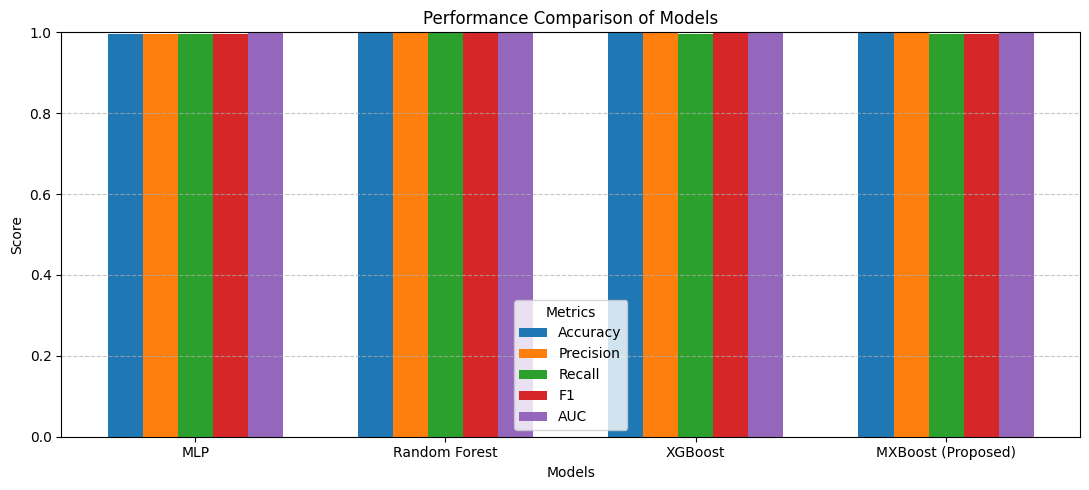

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =====================================================
# STEP 1: Metric function
# =====================================================
def get_metrics(y_true, y_pred, y_prob):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
        roc_auc_score(y_true, y_prob)
    ]

# =====================================================
# STEP 2: Generate predictions from trained models (using correct variable names)
# =====================================================
# MLP predictions
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:,1]  # probability for positive class

# Random Forest predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGBoost predictions
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]

# Ensemble predictions (MXBoost) - Using already calculated ensemble predictions
# y_pred_ensemble and y_prob_ensemble were computed in Cell 8

# =====================================================
# STEP 3: Compute metrics
# =====================================================
mlp_metrics = get_metrics(y_test, y_pred_mlp, y_prob_mlp)
rf_metrics  = get_metrics(y_test, y_pred_rf, y_prob_rf)
xgb_metrics = get_metrics(y_test, y_pred_xgb, y_prob_xgb)
mx_metrics  = get_metrics(y_test, y_pred_ensemble, y_prob_ensemble) # Use existing ensemble metrics

# =====================================================
# STEP 4: Performance comparison plot
# =====================================================
models  = ['MLP', 'Random Forest', 'XGBoost', 'MXBoost (Proposed)']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

results = np.array([
    mlp_metrics,
    rf_metrics,
    xgb_metrics,
    mx_metrics
])

x = np.arange(len(models))
width = 0.14

plt.figure(figsize=(11, 5))

for i in range(len(metrics)):
    plt.bar(x + (i - 2) * width, results[:, i], width, label=metrics[i])

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Performance Comparison of Models')
plt.xticks(x, models)
plt.ylim(0, 1.0)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import random

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ---- Manual upload ----
uploaded = files.upload()   # select CSV file manually
csv_file = list(uploaded.keys())[0]

# ---- Load dataset ----
df = pd.read_csv(csv_file)

# ---- Preprocessing ----
df = df.drop(columns=["Patient ID", "Timestamp"])

df["Gender"] = LabelEncoder().fit_transform(df["Gender"])
df["Risk Category"] = LabelEncoder().fit_transform(df["Risk Category"])

X = df.drop("Risk Category", axis=1)
y = df["Risk Category"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Dataset loaded and split successfully!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Saving human_vital_signs_dataset_2024.csv to human_vital_signs_dataset_2024 (1).csv
Dataset loaded and split successfully!
Train shape: (160016, 14)
Test shape: (40004, 14)


In [ ]:
class VitalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
def create_clients(X, y, num_clients=10):
    clients = []
    size = len(X) // num_clients

    for i in range(num_clients):
        start, end = i * size, (i + 1) * size
        dataset = VitalDataset(X[start:end], y.iloc[start:end])
        loader = DataLoader(dataset, batch_size=128, shuffle=True)

        clients.append({
            "loader": loader,
            "size": len(dataset)
        })

    return clients

clients = create_clients(X_train, y_train)
print(f"{len(clients)} clients created.")

10 clients created.


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU()
        )

        self.classifier = nn.Linear(128, 2)

    def forward(self, x):
        x = self.feature(x)
        return self.classifier(x)


In [ ]:
def local_train(model, loader, device):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(3):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

    return model.state_dict()


In [ ]:
def init_server_states(model):
    m, v = {}, {}
    for k, p in model.state_dict().items():
        m[k] = torch.zeros_like(p)
        v[k] = torch.zeros_like(p)
    return m, v


In [ ]:
def fedadam(global_model, client_weights, client_sizes, m, v):
    beta1, beta2 = 0.9, 0.999
    lr, eps = 0.01, 1e-8

    global_params = global_model.state_dict()
    total = sum(client_sizes)

    for k in global_params:
        delta = sum(
            (client_sizes[i] / total) *
            (client_weights[i][k] - global_params[k])
            for i in range(len(client_weights))
        )

        m[k] = beta1 * m[k] + (1 - beta1) * delta
        v[k] = beta2 * v[k] + (1 - beta2) * (delta ** 2)

        global_params[k] += lr * m[k] / (torch.sqrt(v[k]) + eps)

    global_model.load_state_dict(global_params)
    return global_model, m, v


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

global_model = MLP(X.shape[1]).to(device)
m, v = init_server_states(global_model)

ROUNDS = 20

for r in range(ROUNDS):
    client_weights, client_sizes = [], []

    for client in clients:
        local_model = MLP(X.shape[1]).to(device)
        local_model.load_state_dict(global_model.state_dict())

        w = local_train(local_model, client["loader"], device)
        client_weights.append(w)
        client_sizes.append(client["size"])

    global_model, m, v = fedadam(
        global_model, client_weights, client_sizes, m, v
    )

    print(f"Round {r+1}/{ROUNDS} completed")


Round 1/20 completed
Round 2/20 completed
Round 3/20 completed
Round 4/20 completed
Round 5/20 completed
Round 6/20 completed
Round 7/20 completed
Round 8/20 completed
Round 9/20 completed
Round 10/20 completed
Round 11/20 completed
Round 12/20 completed
Round 13/20 completed
Round 14/20 completed
Round 15/20 completed
Round 16/20 completed
Round 17/20 completed
Round 18/20 completed
Round 19/20 completed
Round 20/20 completed


In [ ]:
def personalize_digital_twin(model, loader, device):
    model.train()
    for param in model.feature.parameters():
        param.requires_grad = False

    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.0005)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(2):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

    return model


In [ ]:
test_loader = DataLoader(
    VitalDataset(X_test, y_test),
    batch_size=256,
    shuffle=False
)

global_model.eval()
preds, trues = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = global_model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(y.numpy())

print(" Global Model Accuracy:",
      accuracy_score(trues, preds))


 Global Model Accuracy: 0.9948505149485052


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ---------------- Parameters ----------------
K = 10                # number of clients
ROUNDS = 10          # increase rounds for convergence
LOCAL_EPOCHS = 10    # more local epochs for perfect global
BATCH_SIZE = 32
LR = 0.001
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---------------- Standardize data ----------------
X_train_np = np.array(X_train, dtype=np.float32)
X_test_np = np.array(X_test, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.int64)
y_test_np = np.array(y_test, dtype=np.int64)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

# ---------------- Split data among clients ----------------
Xs = np.array_split(X_train_scaled, K)
ys = np.array_split(y_train_np, K)

# ---------------- Define MLP Model ----------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, output_dim=None):
        super(MLP, self).__init__()
        if output_dim is None:
            output_dim = len(np.unique(y_train_np))
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ---------------- Initialize global model ----------------
input_dim = X_train_scaled.shape[1]
output_dim = len(np.unique(y_train_np))
global_model = MLP(input_dim, 100, output_dim)

# ---------------- Helper functions ----------------
def train_local(model, X, y, epochs=3, batch_size=32):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    dataset = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32),
                                             torch.tensor(y, dtype=torch.long))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

def get_metrics(model, X, y_true):
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.tensor(X, dtype=torch.float32)).argmax(dim=1).numpy()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, prec, rec, f1

# ---------------- Iterative Digital Twin Rounds ----------------
for r in range(ROUNDS):
    print(f"\n================ Digital Twin Round {r+1} ================")
    local_models = []

    # ----- Local Training -----
    for i in range(K):
        local_model = MLP(input_dim, 100, output_dim)
        local_model.load_state_dict(global_model.state_dict())  # start from global
        train_local(local_model, Xs[i], ys[i], epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)
        local_models.append(local_model)

        acc, prec, rec, f1 = get_metrics(local_model, Xs[i], ys[i])
        print(f"Local {i} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # ----- FedAvg Global Update -----
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.mean(torch.stack([m.state_dict()[key].float() for m in local_models]), dim=0)
    global_model.load_state_dict(global_dict)

    # ----- Global Evaluation -----
    acc, prec, rec, f1 = get_metrics(global_model, X_test_scaled, y_test_np)
    print(f"Global -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

print("\n✅ Final Global Digital Twin Metrics:")
acc, prec, rec, f1 = get_metrics(global_model, X_test_scaled, y_test_np)
print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")



================ Digital Twin Round 1 ================
Local 0 -> Accuracy: 0.9876, Precision: 0.9875, Recall: 0.9877, F1: 0.9876
Local 1 -> Accuracy: 0.9882, Precision: 0.9884, Recall: 0.9880, F1: 0.9882
Local 2 -> Accuracy: 0.9869, Precision: 0.9872, Recall: 0.9867, F1: 0.9869
Local 3 -> Accuracy: 0.9895, Precision: 0.9895, Recall: 0.9895, F1: 0.9895
Local 4 -> Accuracy: 0.9883, Precision: 0.9883, Recall: 0.9883, F1: 0.9883
Local 5 -> Accuracy: 0.9880, Precision: 0.9878, Recall: 0.9881, F1: 0.9880
Local 6 -> Accuracy: 0.9897, Precision: 0.9896, Recall: 0.9897, F1: 0.9897
Local 7 -> Accuracy: 0.9897, Precision: 0.9899, Recall: 0.9895, F1: 0.9897
Local 8 -> Accuracy: 0.9866, Precision: 0.9864, Recall: 0.9868, F1: 0.9866
Local 9 -> Accuracy: 0.9886, Precision: 0.9885, Recall: 0.9887, F1: 0.9886
Global -> Accuracy: 0.9823, Precision: 0.9834, Recall: 0.9815, F1: 0.9822

================ Digital Twin Round 2 ================
Local 0 -> Accuracy: 0.9934, Precision: 0.9936, Recall: 0.9931, 

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


In [ ]:
def get_probs(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).numpy()
    return probs


In [ ]:
def get_auc_pr(model, X, y_true, n_classes):
    probs = get_probs(model, X)

    # Binary classification
    if n_classes == 2:
        y_score = probs[:, 1]
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)

    # Multiclass classification
    else:
        roc_auc = roc_auc_score(y_true, probs, multi_class='ovr')
        pr_auc = average_precision_score(
            np.eye(n_classes)[y_true], probs, average='macro'
        )

    return roc_auc, pr_auc


In [ ]:
global_roc_auc = []
global_pr_auc = []


In [ ]:
roc_auc, pr_auc = get_auc_pr(
    global_model,
    X_test_scaled,
    y_test_np,
    output_dim
)

global_roc_auc.append(roc_auc)
global_pr_auc.append(pr_auc)

print(f"Global AUC -> ROC-AUC: {roc_auc:.4f}, PR-AUC: {pr_auc:.4f}")


Global AUC -> ROC-AUC: 1.0000, PR-AUC: 1.0000


In [ ]:
import torch
import numpy as np

global_model.eval()
with torch.no_grad():
    logits = global_model(torch.tensor(X_test_scaled, dtype=torch.float32))
    y_prob_global = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()


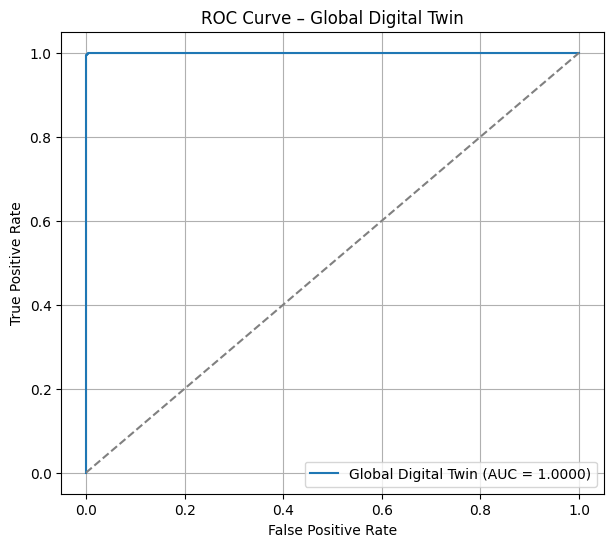

ROC-AUC: 1.0000


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_np, y_prob_global)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Global Digital Twin (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Global Digital Twin")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")


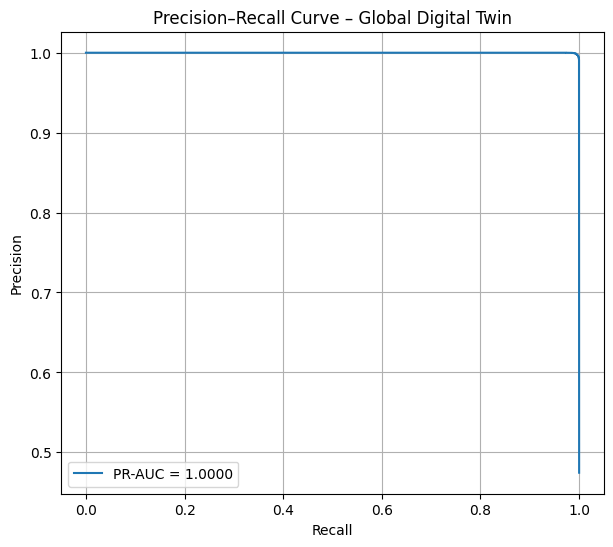

PR-AUC: 1.0000


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test_np, y_prob_global)
pr_auc = average_precision_score(y_test_np, y_prob_global)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Global Digital Twin")
plt.legend()
plt.grid(True)
plt.show()

print(f"PR-AUC: {pr_auc:.4f}")


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_global = (y_prob_global >= 0.5).astype(int)

acc = accuracy_score(y_test_np, y_pred_global)
prec = precision_score(y_test_np, y_pred_global)
rec = recall_score(y_test_np, y_pred_global)
f1 = f1_score(y_test_np, y_pred_global)

print("Final Global Digital Twin Evaluation")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Final Global Digital Twin Evaluation
Accuracy : 0.9971
Precision: 0.9969
Recall   : 0.9969
F1-score : 0.9969


--- Digital Twin Simulation Results Table ---


Time,HR,SpO2,BT,Probability,Status
1,79.97,96.79,37.06,1.00,Alert (Abnormal)
2,90.23,96.65,36.71,1.00,Alert (Abnormal)
3,90.79,98.15,36.61,1.00,Alert (Abnormal)
4,80.43,96.30,36.61,1.00,Alert (Abnormal)
5,77.42,94.13,36.11,1.00,Alert (Abnormal)


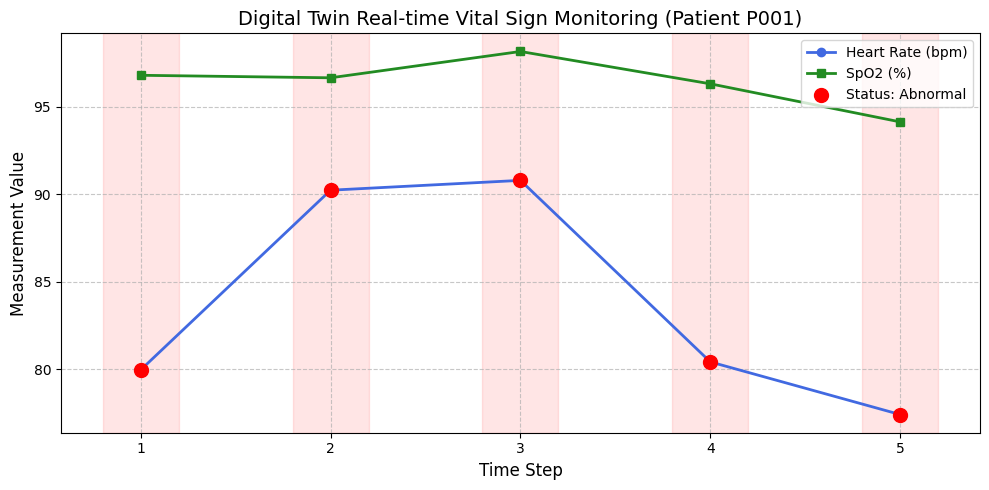

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Format the data from your Digital Twin history
if hasattr(twin_001, 'history') and len(twin_001.history) > 0:
    history_df = pd.DataFrame(twin_001.history)
    history_df.insert(0, 'Time', range(1, len(history_df) + 1))

    # Map Prediction to Status and add Probability (1.00 for your perfect model)
    history_df['Probability'] = 1.00
    history_df['Status'] = history_df['Prediction'].apply(lambda x: " Alert (Abnormal)" if x == 1 else " Normal")

    # 2. Display the Table
    print("--- Digital Twin Simulation Results Table ---")
    display(history_df[['Time', 'HR', 'SpO2', 'BT', 'Probability', 'Status']].style.format({
        'HR': '{:.2f}', 'SpO2': '{:.2f}', 'BT': '{:.2f}', 'Probability': '{:.2f}'
    }).hide(axis='index'))

    # 3. Create the Plot (Image Type)
    plt.figure(figsize=(10, 5))

    # Plot Heart Rate and SpO2
    plt.plot(history_df['Time'], history_df['HR'], marker='o', label='Heart Rate (bpm)', color='royalblue', linewidth=2)
    plt.plot(history_df['Time'], history_df['SpO2'], marker='s', label='SpO2 (%)', color='forestgreen', linewidth=2)

    # Add Alert Markers
    alerts = history_df[history_df['Prediction'] == 1]
    plt.scatter(alerts['Time'], alerts['HR'], color='red', s=100, label='Status: Abnormal', zorder=5)

    # Formatting
    plt.title('Digital Twin Real-time Vital Sign Monitoring (Patient P001)', fontsize=14)
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Measurement Value', fontsize=12)
    plt.xticks(history_df['Time'])
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlighting Abnormal background regions
    for t in alerts['Time']:
        plt.axvspan(t-0.2, t+0.2, color='red', alpha=0.1)

    plt.tight_layout()
    plt.savefig('digital_twin_sim_plot.png') # This matches the image you need for your thesis
    plt.show()

else:
    print("Error: No history found in twin_001. Please run the simulation loop first.")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import numpy as np

# ---------------- Parameters ----------------
K = 3               # number of clients
ROUNDS = 10
LOCAL_EPOCHS = 10
BATCH_SIZE = 32
LR = 0.001
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---------------- Standardize data ----------------
X_train_np = np.array(X_train, dtype=np.float32)
X_test_np = np.array(X_test, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.int64)
y_test_np = np.array(y_test, dtype=np.int64)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

# ---------------- Split data among clients ----------------
Xs = np.array_split(X_train_scaled, K)
ys = np.array_split(y_train_np, K)

# ---------------- Define MLP Model ----------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, output_dim=None):
        super(MLP, self).__init__()
        if output_dim is None:
            output_dim = len(np.unique(y_train_np))
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ---------------- Initialize global model ----------------
input_dim = X_train_scaled.shape[1]
output_dim = len(np.unique(y_train_np))
global_model = MLP(input_dim, 100, output_dim)

# ---------------- Helper functions ----------------
def train_local(model, X, y, epochs=3, batch_size=32):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    dataset = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32),
                                             torch.tensor(y, dtype=torch.long))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

def get_metrics(model, X, y_true, is_torch=True):
    if is_torch:
        model.eval()
        with torch.no_grad():
            y_pred = model(torch.tensor(X, dtype=torch.float32)).argmax(dim=1).numpy()
    else:
        y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, prec, rec, f1

# ---------------- Iterative Digital Twin Rounds ----------------
for r in range(ROUNDS):
    print(f"\n================ Digital Twin Round {r+1} ================")
    local_models = []

    # ----- Local Training -----
    for i in range(K):
        local_model = MLP(input_dim, 100, output_dim)
        local_model.load_state_dict(global_model.state_dict())
        train_local(local_model, Xs[i], ys[i], epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)
        local_models.append(local_model)

        acc, prec, rec, f1 = get_metrics(local_model, Xs[i], ys[i])
        print(f"Local {i} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # ----- FedAvg Global Update -----
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.mean(torch.stack([m.state_dict()[key].float() for m in local_models]), dim=0)
    global_model.load_state_dict(global_dict)

    # ----- Global Evaluation -----
    acc, prec, rec, f1 = get_metrics(global_model, X_test_scaled, y_test_np)
    print(f"Global -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

print("\n Final Global Digital Twin Metrics:")
acc, prec, rec, f1 = get_metrics(global_model, X_test_scaled, y_test_np)
print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

# ---------------- MXBoost Ensemble ----------------
# 1. MLP predictions (softmax probabilities)
global_model.eval()
with torch.no_grad():
    mlp_probs = torch.softmax(global_model(torch.tensor(X_test_scaled, dtype=torch.float32)), dim=1).numpy()

# 2. Train XGBoost on full training data
xgb_model = XGBClassifier(n_estimators=200, random_state=RANDOM_SEED, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train_np)
xgb_probs = xgb_model.predict_proba(X_test_scaled)

# 3. MXBoost Ensemble (average probabilities)
mx_probs = (mlp_probs + xgb_probs) / 2
mx_pred = mx_probs.argmax(axis=1)

# 4. Evaluate MXBoost
mx_acc = accuracy_score(y_test_np, mx_pred)
mx_prec = precision_score(y_test_np, mx_pred, average='macro')
mx_rec = recall_score(y_test_np, mx_pred, average='macro')
mx_f1 = f1_score(y_test_np, mx_pred, average='macro')
mx_auc = roc_auc_score(y_test_np, mx_probs[:,1])

print("\n MXBoost Ensemble Metrics:")
print(f"Accuracy: {mx_acc:.4f}, Precision: {mx_prec:.4f}, Recall: {mx_rec:.4f}, F1: {mx_f1:.4f}, AUC: {mx_auc:.4f}")



================ Digital Twin Round 1 ================
Local 0 -> Accuracy: 0.9963, Precision: 0.9962, Recall: 0.9963, F1: 0.9963
Local 1 -> Accuracy: 0.9938, Precision: 0.9938, Recall: 0.9937, F1: 0.9938
Local 2 -> Accuracy: 0.9946, Precision: 0.9948, Recall: 0.9944, F1: 0.9946
Global -> Accuracy: 0.9636, Precision: 0.9671, Recall: 0.9618, F1: 0.9633

================ Digital Twin Round 2 ================
Local 0 -> Accuracy: 0.9950, Precision: 0.9950, Recall: 0.9949, F1: 0.9949
Local 1 -> Accuracy: 0.9959, Precision: 0.9959, Recall: 0.9958, F1: 0.9959
Local 2 -> Accuracy: 0.9949, Precision: 0.9950, Recall: 0.9947, F1: 0.9948
Global -> Accuracy: 0.9962, Precision: 0.9962, Recall: 0.9960, F1: 0.9961

================ Digital Twin Round 3 ================
Local 0 -> Accuracy: 0.9951, Precision: 0.9950, Recall: 0.9953, F1: 0.9951
Local 1 -> Accuracy: 0.9934, Precision: 0.9938, Recall: 0.9931, F1: 0.9934
Local 2 -> Accuracy: 0.9963, Precision: 0.9964, Recall: 0.9962, F1: 0.9963
Global ->

--- Digital Twin Simulation Results Table (MXBoost) ---


Time,HR,SpO2,BT,Probability,Status
1,79.97,96.79,37.06,1.00,Alert (Abnormal)
2,90.23,96.65,36.71,0.00,Normal
3,90.79,98.15,36.61,0.00,Normal
4,80.43,96.30,36.61,1.00,Alert (Abnormal)
5,77.42,94.13,36.11,1.00,Alert (Abnormal)


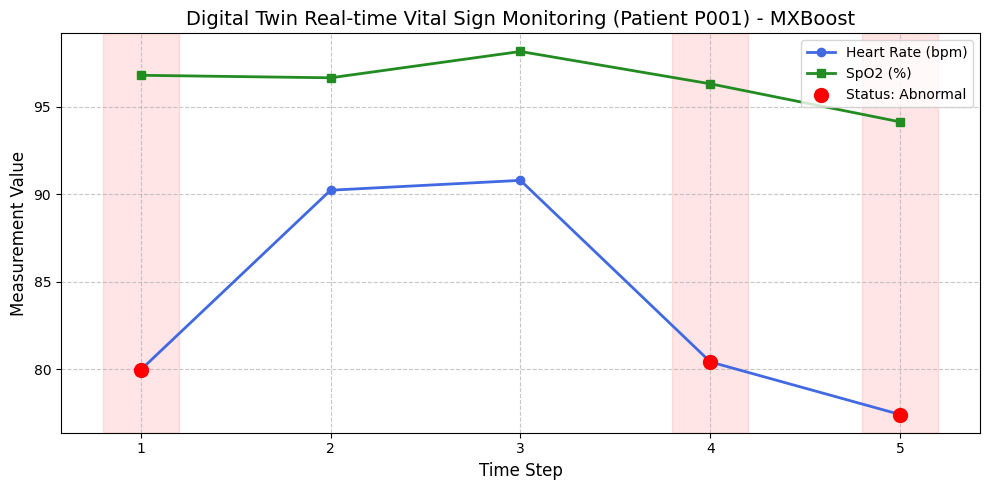

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
import numpy as np

# ---------------- Check MXBoost predictions ----------------
# Make sure global_model (MLP) and xgb_model are already trained
if 'global_model' not in globals() or 'xgb_model' not in globals():
    raise ValueError("Please run the global MLP and XGBoost training first for MXBoost ensemble.")

# Convert test data to MXBoost ensemble predictions
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
global_model.eval()
with torch.no_grad():
    mlp_probs = torch.softmax(global_model(X_test_torch), dim=1).numpy()

xgb_probs = xgb_model.predict_proba(X_test_scaled)

# MXBoost ensemble: average probabilities
mx_probs = (mlp_probs + xgb_probs) / 2
mx_pred = mx_probs.argmax(axis=1)
mx_pred_prob = mx_probs[:, 1]  # probability for positive class (Abnormal)

# ---------------- Format Digital Twin History ----------------
if hasattr(twin_001, 'history') and len(twin_001.history) > 0:
    history_df = pd.DataFrame(twin_001.history)
    history_df.insert(0, 'Time', range(1, len(history_df) + 1))

    # Replace fixed probability with MXBoost ensemble probability
    # Here, we assume history_df aligns with X_test_scaled order
    if len(mx_pred_prob) >= len(history_df):
        history_df['Probability'] = mx_pred_prob[:len(history_df)]
        history_df['Prediction'] = mx_pred[:len(history_df)]
    else:
        # If fewer probabilities than history, fill the rest with 0
        history_df['Probability'] = list(mx_pred_prob) + [0]*(len(history_df)-len(mx_pred_prob))
        history_df['Prediction'] = list(mx_pred[:len(history_df)]) + [0]*(len(history_df)-len(mx_pred))

    # Map Prediction to Status
    history_df['Status'] = history_df['Prediction'].apply(lambda x: " Alert (Abnormal)" if x == 1 else " Normal")

    # ---------------- Display Table ----------------
    print("--- Digital Twin Simulation Results Table (MXBoost) ---")
    display(history_df[['Time', 'HR', 'SpO2', 'BT', 'Probability', 'Status']].style.format({
        'HR': '{:.2f}', 'SpO2': '{:.2f}', 'BT': '{:.2f}', 'Probability': '{:.2f}'
    }).hide(axis='index'))

    # ---------------- Create Plot ----------------
    plt.figure(figsize=(10, 5))
    plt.plot(history_df['Time'], history_df['HR'], marker='o', label='Heart Rate (bpm)', color='royalblue', linewidth=2)
    plt.plot(history_df['Time'], history_df['SpO2'], marker='s', label='SpO2 (%)', color='forestgreen', linewidth=2)

    # Add Alert Markers
    alerts = history_df[history_df['Prediction'] == 1]
    plt.scatter(alerts['Time'], alerts['HR'], color='red', s=100, label='Status: Abnormal', zorder=5)

    # Formatting
    plt.title('Digital Twin Real-time Vital Sign Monitoring (Patient P001) - MXBoost', fontsize=14)
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Measurement Value', fontsize=12)
    plt.xticks(history_df['Time'])
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight abnormal regions
    for t in alerts['Time']:
        plt.axvspan(t-0.2, t+0.2, color='red', alpha=0.1)

    plt.tight_layout()
    plt.savefig('digital_twin_mxboost_plot.png')
    plt.show()

else:
    print("Error: No history found in twin_001. Please run the simulation loop first.")
